In [ ]:
import kagglehub
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
import seaborn as sns
import cv2

In [ ]:
TRAIN_DIR   = os.path.join(path, "Train")
TEST_DIR    = os.path.join(path, "Test")
TEST_CSV    = os.path.join(path, "Test.csv")

In [ ]:
NUM_CLASSES = 43
CLASS_NAMES = {
    0:'Speed limit (20)',    1:'Speed limit (30)',   2:'Speed limit (50)',
    3:'Speed limit (60)',    4:'Speed limit (70)',   5:'Speed limit (80)',
    6:'End speed limit(80)', 7:'Speed limit (100)',  8:'Speed limit (120)',
    9:'No passing',         10:'No passing >3.5t',  11:'Right-of-way',
    12:'Priority road',     13:'Yield',              14:'Stop',
    15:'No vehicles',       16:'No >3.5t vehicles', 17:'No entry',
    18:'General caution',   19:'Danger curve left', 20:'Danger curve right',
    21:'Double curve',      22:'Bumpy road',         23:'Slippery road',
    24:'Road narrows',      25:'Road work',          26:'Traffic signals',
    27:'Pedestrians',       28:'Children crossing',  29:'Bicycles crossing',
    30:'Ice/snow',          31:'Wild animals',       32:'End speed+passing',
    33:'Turn right ahead',  34:'Turn left ahead',    35:'Ahead only',
    36:'Go straight/right', 37:'Go straight/left',   38:'Keep right',
    39:'Keep left',         40:'Roundabout',          41:'End no passing',
    42:'End no passing >3.5t'
}

In [ ]:
print("Loading data from folder structure...")

train_paths = []
train_labels = []

# Loop through each class folder (0 to 42)
for class_id in tqdm(range(NUM_CLASSES), desc="Scanning class folders"):
    class_folder = os.path.join(TRAIN_DIR, str(class_id))
    if os.path.exists(class_folder):
        # Get all PNG files in the folder
        for img_file in os.listdir(class_folder):
            if img_file.endswith('.png'):
                img_path = os.path.join(class_folder, img_file)
                train_paths.append(img_path)
                train_labels.append(class_id)

print(f"\nTotal training images found: {len(train_paths):,}")

Loading data from folder structure...


Scanning class folders: 100%|██████████| 43/43 [00:00<00:00, 192.38it/s]


Total training images found: 39,209


In [ ]:
# Check class distribution
class_counts = Counter(train_labels)
most_common = class_counts.most_common(1)[0]
least_common = min(class_counts.items(), key=lambda x: x[1])
print(f"Most common class     : {CLASS_NAMES[most_common[0]]} ({most_common[1]} imgs)")
print(f"Least common class    : {CLASS_NAMES[least_common[0]]} ({least_common[1]} imgs)")

Most common class     : Speed limit (50) (2250 imgs)
Least common class    : Speed limit (20) (210 imgs)


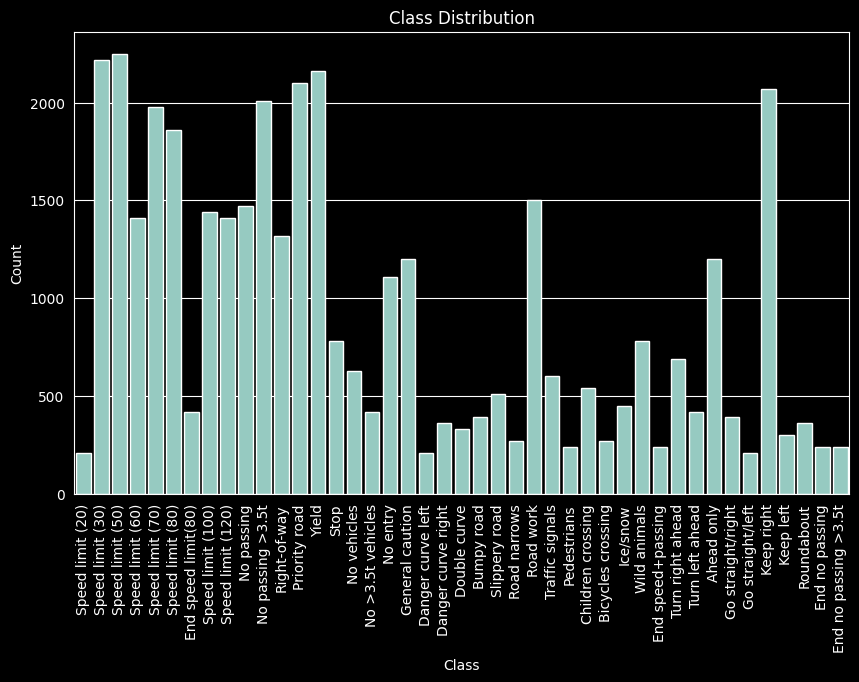

In [ ]:
# visualize class balance
plt.figure(figsize=(10, 6))
sns.barplot(x=list(CLASS_NAMES.values()), y=list(class_counts.values()))
plt.xticks(rotation=90)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

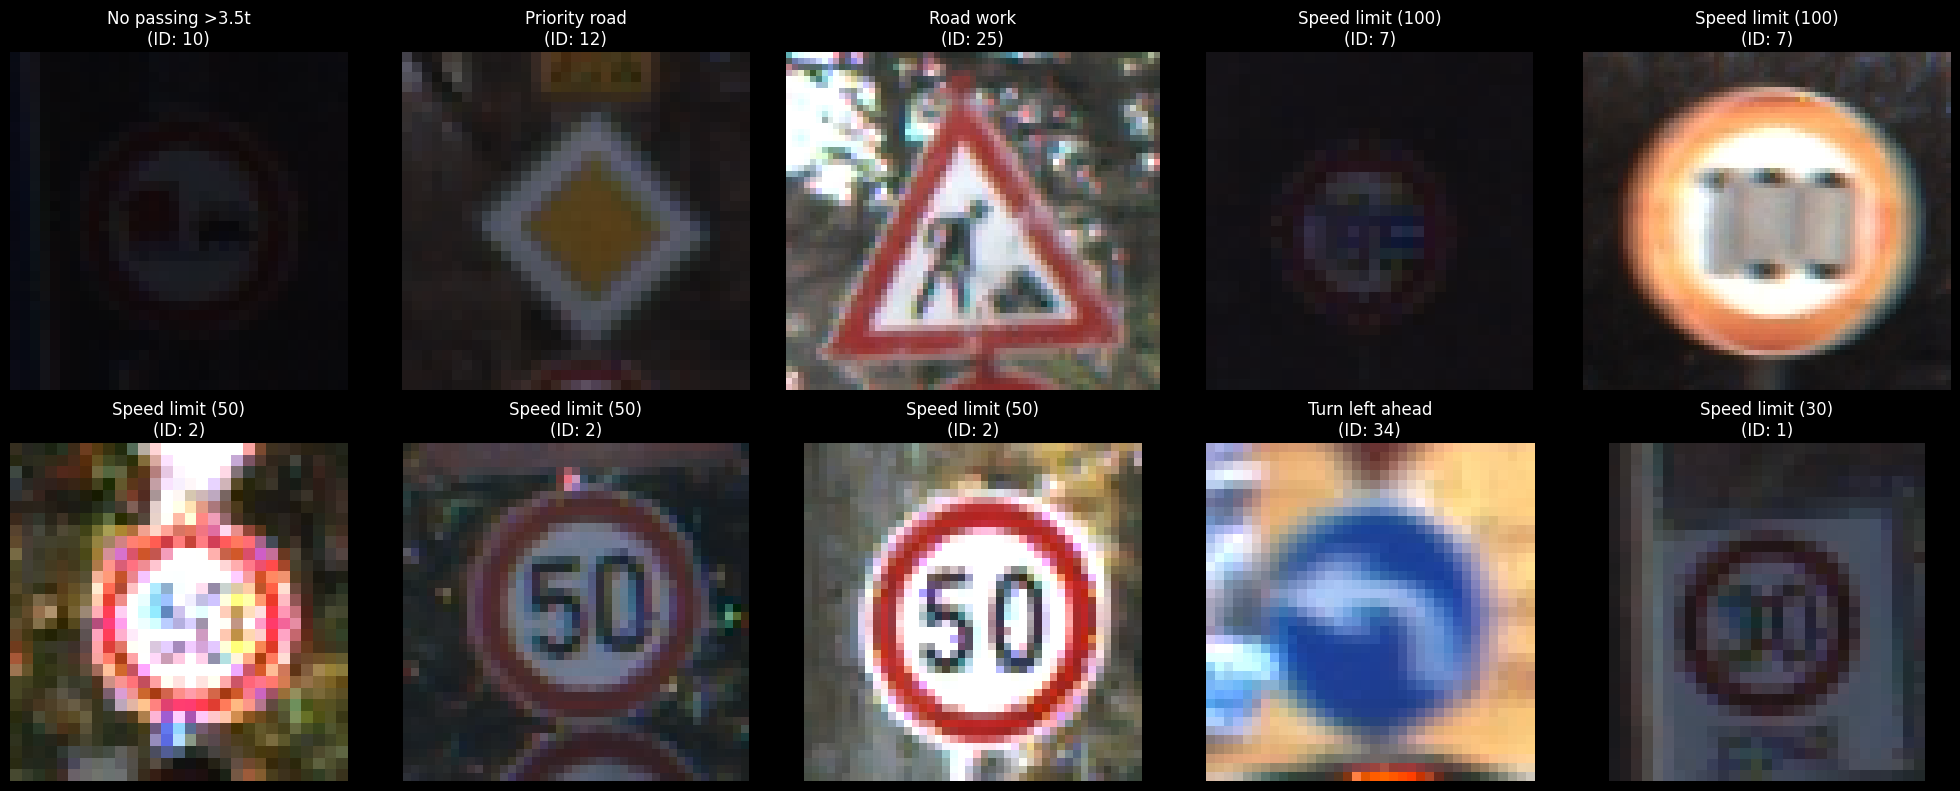

In [ ]:
# show sample images
num_samples = 10
indices = np.random.choice(len(train_paths), num_samples, replace=False)

plt.figure(figsize=(20, 8))
for i, idx in enumerate(indices):
    img_path = train_paths[idx]
    label = train_labels[idx]

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"{CLASS_NAMES[label]}\n(ID: {label})")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# pixel statistics

# mean and std per channel (RGB)
sums = np.zeros(3)
sum_sqs = np.zeros(3)
pixel_count = 0

# swample for speed (every 2nd image)
for img_path in tqdm(train_paths[::2], desc="Processing the potato in images"):
    img = cv2.imread(img_path)
    if img is None: continue

    # Convert BGR (OpenCV default) to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Normalize to [0, 1]
    img = img.astype(np.float32) / 255.0

    sums += np.sum(img, axis=(0, 1))
    sum_sqs += np.sum(img**2, axis=(0, 1))
    pixel_count += img.shape[0] * img.shape[1]

mean = sums / pixel_count
std = np.sqrt((sum_sqs / pixel_count) - (mean**2))

print(f"\nDataset Statistics (RGB):")
print(f"Mean: {mean}")
print(f"Std:  {std}")

Processing the potato in images: 100%|██████████| 19605/19605 [00:22<00:00, 866.32it/s] 


Dataset Statistics (RGB):
Mean: [0.37542943 0.34546535 0.35496636]
Std:  [0.29935843 0.29276565 0.29924224]


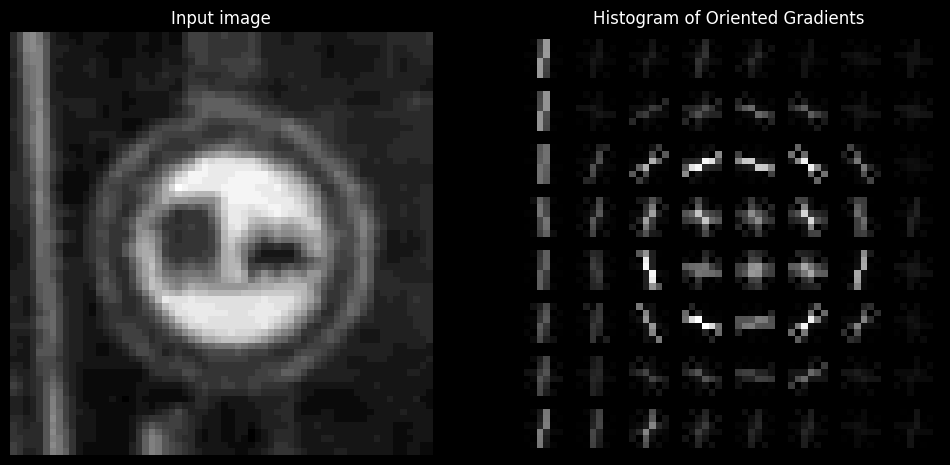

HOG feature vector shape: (512,)


In [ ]:
from skimage.feature import hog
from skimage import exposure

# sample image to visualize HOG
img_path = train_paths[indices[0]]
img = cv2.imread(img_path)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_resized = cv2.resize(img_gray, (64, 64))

fd, hog_image = hog(img_resized, orientations=8, pixels_per_cell=(8, 8),
                    cells_per_block=(1, 1), visualize=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

ax1.axis('off')
ax1.imshow(img_resized, cmap=plt.cm.gray)
ax1.set_title('Input image')

# Rescale histogram for better display
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))

ax2.axis('off')
ax2.imshow(hog_image_rescaled, cmap=plt.cm.gray)
ax2.set_title('Histogram of Oriented Gradients')
plt.show()

print(f'HOG feature vector shape: {fd.shape}')

In [ ]:
from sklearn.decomposition import PCA
def extract_hog(img_path):
    # Load and preprocess
    img = cv2.imread(img_path)
    if img is None: return None
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_resized = cv2.resize(img_gray, (64, 64))

    # Extract HOG
    fd = hog(img_resized, orientations=8, pixels_per_cell=(8, 8),
             cells_per_block=(1, 1), visualize=False)
    return fd

print(f"Extracting HOG features for {len(train_paths)} images...")
hog_features = []

# Extracting for all images
for path in tqdm(train_paths, desc="HOG Extraction"):
    features = extract_hog(path)
    if features is not None:
        hog_features.append(features)

# Features reduction using PCA
X_train = np.array(hog_features)
X_train_pca = PCA(n_components=128).fit_transform(X_train)
y_train = np.array(train_labels)

print(f"\nFeature extraction complete.")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

Extracting HOG features for 39209 images...


HOG Extraction: 100%|██████████| 39209/39209 [01:47<00:00, 364.07it/s]



Feature extraction complete.
X_train shape: (39209, 512)
y_train shape: (39209,)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_auc_score

# Naive bayes before PCA
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)


print(f"Training Naive Bayes on {len(X_train_nb)} samples...")

nb = GaussianNB()
nb.fit(X_train_nb, y_train_nb)

# Prediction
y_pred_nb = nb.predict(X_test_nb)
y_prob_nb = nb.predict_proba(X_test_nb)

# Evaluation
print(f"\n Naive Bayes Validation Accuracy: {accuracy_score(y_test_nb, y_pred_nb):.4f}")
print("\nDetailed Naive Bayes Classification Report:")
print(classification_report(y_test_nb, y_pred_nb))
print("\nROC_AUC score:")
print(roc_auc_score(y_test_nb, y_prob_nb, multi_class= "ovr"))

Training Naive Bayes on 31367 samples...

 Naive Bayes Validation Accuracy: 0.8049

Detailed Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.29      0.74      0.41        42
           1       0.66      0.67      0.67       444
           2       0.71      0.56      0.62       450
           3       0.79      0.50      0.62       282
           4       0.86      0.71      0.78       396
           5       0.60      0.53      0.56       372
           6       0.99      0.88      0.93        84
           7       0.69      0.65      0.67       288
           8       0.46      0.64      0.53       282
           9       0.86      0.80      0.83       294
          10       0.77      0.86      0.82       402
          11       0.82      0.84      0.83       264
          12       0.95      1.00      0.97       420
          13       1.00      0.99      0.99       432
          14       0.99      0.87      0.93       156
       

In [ ]:
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X_train_pca, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Naive bayes after PCA

nb = GaussianNB()
nb.fit(X_train_nb, y_train_nb)

# Prediction
y_pred_nb = nb.predict(X_test_nb)
y_prob_nb = nb.predict_proba(X_test_nb)

# Evaluation
print(f"\n Naive Bayes Validation Accuracy: {accuracy_score(y_test_nb, y_pred_nb):.4f}")
print("\nDetailed Naive Bayes Classification Report:")
print(classification_report(y_test_nb, y_pred_nb))
print("\nROC_AUC score:")
print(roc_auc_score(y_test_nb, y_prob_nb, multi_class= "ovr"))

Training Naive Bayes on 31367 samples...
smoothing var:  1e-09

 Naive Bayes Validation Accuracy: 0.8458

Detailed Naive Bayes Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.74      0.66        42
           1       0.71      0.77      0.74       444
           2       0.68      0.72      0.70       450
           3       0.79      0.72      0.75       282
           4       0.98      0.81      0.88       396
           5       0.63      0.71      0.67       372
           6       1.00      0.90      0.95        84
           7       0.81      0.77      0.79       288
           8       0.76      0.72      0.74       282
           9       0.87      0.87      0.87       294
          10       0.87      0.89      0.88       402
          11       0.75      0.74      0.74       264
          12       0.96      1.00      0.98       420
          13       1.00      0.99      0.99       432
          14       1.00      0.92      

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# KNN before PCA
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training KNN on {len(X_train_split)} samples...")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_split, y_train_split)

# Predict and evaluate
y_pred_knn = knn.predict(X_val_split)
y_prob_knn = knn.predict_proba(X_val_split)

print(f"\nKNN Validation Accuracy: {accuracy_score(y_val_split, y_pred_knn):.4f}")
print("\nDetailed KNN Classification Report:")
print(classification_report(y_val_split, y_pred_knn, target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)]))
print("\nROC_AUC score:")
print(roc_auc_score(y_val_split, y_prob_knn, multi_class= "ovr"))

Training KNN on 31367 samples...

KNN Validation Accuracy: 0.9580

Detailed KNN Classification Report:
                      precision    recall  f1-score   support

    Speed limit (20)       0.97      0.88      0.93        42
    Speed limit (30)       0.94      0.95      0.95       444
    Speed limit (50)       0.84      0.94      0.89       450
    Speed limit (60)       0.95      0.91      0.93       282
    Speed limit (70)       0.91      0.96      0.93       396
    Speed limit (80)       0.88      0.91      0.90       372
 End speed limit(80)       1.00      0.99      0.99        84
   Speed limit (100)       0.95      0.88      0.91       288
   Speed limit (120)       0.90      0.94      0.92       282
          No passing       0.98      0.98      0.98       294
    No passing >3.5t       0.98      0.94      0.96       402
        Right-of-way       0.97      0.97      0.97       264
       Priority road       0.99      1.00      1.00       420
               Yield       1

In [ ]:
# KNN after PCA
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_pca, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Training KNN on {len(X_train_split)} samples...")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_split, y_train_split)

# Predict and evaluate
y_pred_knn = knn.predict(X_val_split)
y_prob_knn = knn.predict_proba(X_val_split)

print(f"\nKNN Validation Accuracy: {accuracy_score(y_val_split, y_pred_knn):.4f}")
print("\nDetailed KNN Classification Report:")
print(classification_report(y_val_split, y_pred_knn, target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)]))
print("\nROC_AUC score:")
print(roc_auc_score(y_val_split, y_prob_knn, multi_class= "ovr"))

Training KNN on 31367 samples...

KNN Validation Accuracy: 0.9601

Detailed KNN Classification Report:
                      precision    recall  f1-score   support

    Speed limit (20)       0.97      0.83      0.90        42
    Speed limit (30)       0.93      0.94      0.94       444
    Speed limit (50)       0.88      0.94      0.91       450
    Speed limit (60)       0.92      0.91      0.91       282
    Speed limit (70)       0.92      0.96      0.94       396
    Speed limit (80)       0.89      0.90      0.89       372
 End speed limit(80)       1.00      0.98      0.99        84
   Speed limit (100)       0.95      0.90      0.92       288
   Speed limit (120)       0.93      0.95      0.94       282
          No passing       0.96      0.99      0.98       294
    No passing >3.5t       0.99      0.95      0.97       402
        Right-of-way       0.95      0.96      0.95       264
       Priority road       0.99      1.00      1.00       420
               Yield       1

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import pandas as pd

# Stratify ensures the class balance is maintained in both sets
X_train_ens, X_val_ens, y_train_ens, y_val_ens = train_test_split(
    X_train_pca, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print(f"Data split complete.")
print(f"Training samples: {X_train_ens.shape[0]} | Validation samples: {X_val_ens.shape[0]}")

Data split complete.
Training samples: 31367 | Validation samples: 7842


In [ ]:
print("Training Random Forest (Bagging)...")

# Initialize and train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_ens, y_train_ens)

# Predict
y_pred_rf = rf_model.predict(X_val_ens)
y_prob_rf = rf_model.predict_proba(X_val_ens)

print(f"RF Validation Accuracy: {accuracy_score(y_val_ens, y_pred_rf):.4f}")

Training Random Forest (Bagging)...
RF Validation Accuracy: 0.8674


In [ ]:
print("Training XGBoost (Boosting)...")

# Initialize and train
# 'mlogloss' is the standard loss function for multi-class classification
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                          use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_ens, y_train_ens)

# Predict
y_pred_xgb = xgb_model.predict(X_val_ens)
y_prob_xgb = xgb_model.predict_proba(X_val_ens)

print(f"XGBoost Validation Accuracy: {accuracy_score(y_val_ens, y_pred_xgb):.4f}")

Training XGBoost (Boosting)...


/run/media/islam/6cd0d34e-fc8d-4fdf-952e-4c1c86fd93e8/FCAI/Level3/2/supervised/Autonomous-Vehicle-Perception-Module/.venv/lib64/python3.14/site-packages/xgboost/training.py:200: UserWarning: [07:35:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Validation Accuracy: 0.8884


In [ ]:
# ensemble report
print("\n" + "="*30)
print("RANDOM FOREST REPORT")
print("="*30)
print(classification_report(y_val_ens, y_pred_rf))

print("\n" + "="*30)
print("XGBOOST REPORT")
print("="*30)
print(classification_report(y_val_ens, y_pred_xgb))

# Final Comparison Table
summary = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_val_ens, y_pred_rf), accuracy_score(y_val_ens, y_pred_xgb)],
    'ROC-AUC': [roc_auc_score(y_val_ens, y_prob_rf, multi_class='ovr'),
                roc_auc_score(y_val_ens, y_prob_xgb, multi_class='ovr')]
})

print("\nFinal Ensemble Comparison:")
print(summary)


RANDOM FOREST REPORT
              precision    recall  f1-score   support

           0       1.00      0.26      0.42        42
           1       0.76      0.87      0.81       444
           2       0.68      0.84      0.75       450
           3       0.86      0.74      0.80       282
           4       0.88      0.87      0.88       396
           5       0.75      0.72      0.73       372
           6       0.97      0.93      0.95        84
           7       0.85      0.81      0.83       288
           8       0.87      0.75      0.80       282
           9       0.84      0.92      0.88       294
          10       0.88      0.95      0.91       402
          11       0.65      0.93      0.76       264
          12       0.98      0.99      0.99       420
          13       0.98      1.00      0.99       432
          14       1.00      0.92      0.96       156
          15       1.00      0.75      0.86       126
          16       1.00      0.96      0.98        84
     

In [ ]:
#split
X_train_grid, X_val_grid, y_train_grid, y_val_grid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [ ]:
#tuning hyperparameters for KNN and naive bayes using grid search
from sklearn.model_selection import GridSearchCV

# KNN hyperparameter tuning
knn_params = {
    'n_neighbors': np.arange(2, 11, 1),
    'metric': ['euclidean', 'manhattan']
}

#gird searching
print("training grid search on KNN...")
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, n_jobs=-1, verbose=1, scoring='accuracy')

knn_grid.fit(X_train_grid, y_train_grid)
print("best parameters: ", knn_grid.best_params_)

#print result of prediction
y_pred_grid_knn = knn_grid.predict(X_val_grid)
y_prob_grid_knn = knn_grid.predict_proba(X_val_grid)
print("\nClassification Report:\n", classification_report(y_val_grid, y_pred_grid_knn))


training grid search on KNN...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
best parameters:  {'metric': 'manhattan', 'n_neighbors': np.int64(3)}

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.96      0.95       444
           2       0.92      0.94      0.93       450
           3       0.91      0.93      0.92       282
           4       0.95      0.96      0.96       396
           5       0.89      0.94      0.91       372
           6       1.00      1.00      1.00        84
           7       0.95      0.91      0.93       288
           8       0.96      0.95      0.96       282
           9       0.99      0.99      0.99       294
          10       0.99      0.98      0.98       402
          11       0.96      0.98      0.97       264
          12       1.00      1.00      1.00       420
          13       1.00      1.00      1.00       432
  

ValueError: multi_class must be in ('ovo', 'ovr')

In [ ]:
print("roc_auc: ", roc_auc_score(y_val_grid, y_prob_grid_knn, multi_class='ovr'))

roc_auc:  0.9961708538362436


In [ ]:
#grid search for naive bayes (PCA)
naive_bayes_params = {
    'var_smoothing': np.logspace(0, -9, num=100) #100 values from 1.0 to 10^-9
}

#X_train_nb, X_test_nb, y_train_nb and y_test_nb are values after pca
print("training grid search on Naive Bayes...")
nb_grid = GridSearchCV(GaussianNB(), naive_bayes_params, cv=5, n_jobs=-1, verbose=1, scoring='accuracy')
nb_grid.fit(X_train_nb, y_train_nb)
print("best parameters: ", nb_grid.best_params_)

y_pred_grid_nb = nb_grid.predict(X_test_nb)
y_prob_grid_nb = nb_grid.predict_proba(X_test_nb)
print("\nClassification Report:\n", classification_report(y_test_nb, y_pred_grid_nb))
print("roc_auc: ", roc_auc_score(y_test_nb, y_prob_grid_nb, multi_class='ovr'))

training grid search on Naive Bayes...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
best parameters:  {'var_smoothing': np.float64(2.848035868435799e-05)}

Classification Report:
               precision    recall  f1-score   support

           0       0.29      0.74      0.41        42
           1       0.66      0.67      0.67       444
           2       0.71      0.56      0.62       450
           3       0.79      0.50      0.62       282
           4       0.86      0.71      0.78       396
           5       0.60      0.53      0.56       372
           6       0.99      0.88      0.93        84
           7       0.69      0.65      0.67       288
           8       0.46      0.64      0.53       282
           9       0.86      0.80      0.83       294
          10       0.77      0.86      0.82       402
          11       0.82      0.84      0.83       264
          12       0.95      1.00      0.97       420
          13       1.00      0.99      0.99  

In [ ]:
print("Loading test data from folder structure...")

test_paths = []
#looping on the images to load them
for img_file in os.listdir(TEST_DIR):
    if img_file.endswith('.png'):
        img_path = os.path.join(TEST_DIR, img_file)
        test_paths.append(img_path)

print(f"\nTotal test images found: {len(test_paths):,}")

Loading test data from folder structure...

Total test images found: 12,630


In [ ]:
print(f"Extracting HOG features for {len(test_paths)} images...")
hog_features = []

# Extracting for all images
for path in tqdm(test_paths, desc="HOG Extraction"):
    features = extract_hog(path)
    if features is not None:
        hog_features.append(features)

# Features reduction using PCA
X_test = np.array(hog_features)
X_test_pca = PCA(n_components=128).fit_transform(X_test)

print(f"\nFeature extraction complete.")
print(f"X_test shape: {X_test.shape}")

Extracting HOG features for 12630 images...


HOG Extraction: 100%|██████████| 12630/12630 [00:11<00:00, 1106.44it/s]



Feature extraction complete.
X_test shape: (12630, 512)


In [ ]:
#now we load test labels from the csv file
test_df = pd.read_csv(TEST_CSV)
y_test = test_df['ClassId'].values
print(f"Test labels loaded: {len(y_test)} samples")

Test labels loaded: 12630 samples


In [ ]:
#we predict using the best KNN model
y_pred_test_knn = knn_grid.predict(X_test)
y_prob_test_knn = knn_grid.predict_proba(X_test)
print("\nKNN Test Classification Report:\n", classification_report(y_test, y_pred_test_knn))
print("KNN Test ROC_AUC: ", roc_auc_score(y_test, y_prob_test_knn, multi_class='ovr'))


KNN Test Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.28      0.35        60
           1       0.60      0.52      0.55       720
           2       0.45      0.68      0.54       750
           3       0.42      0.44      0.43       450
           4       0.72      0.76      0.74       660
           5       0.40      0.63      0.49       630
           6       0.88      0.64      0.74       150
           7       0.60      0.56      0.58       450
           8       0.61      0.65      0.63       450
           9       0.82      0.63      0.71       480
          10       0.78      0.76      0.77       660
          11       0.57      0.67      0.61       420
          12       0.96      1.00      0.98       690
          13       1.00      0.99      1.00       720
          14       0.98      0.87      0.92       270
          15       0.96      0.71      0.82       210
          16       0.71      0.91      0.80    

In [ ]:
#we predict using the best Naive Bayes model
y_pred_test_nb = nb_grid.predict(X_test)
y_prob_test_nb = nb_grid.predict_proba(X_test)
print("\nNaive Bayes Test Classification Report:\n", classification_report(y_test, y_pred_test_nb))
print("Naive Bayes Test ROC_AUC: ", roc_auc_score(y_test, y_prob_test_nb, multi_class='ovr'))


Naive Bayes Test Classification Report:
               precision    recall  f1-score   support

           0       0.28      0.68      0.40        60
           1       0.67      0.58      0.63       720
           2       0.61      0.56      0.58       750
           3       0.77      0.48      0.59       450
           4       0.82      0.63      0.71       660
           5       0.54      0.53      0.54       630
           6       0.96      0.72      0.82       150
           7       0.71      0.63      0.67       450
           8       0.46      0.67      0.54       450
           9       0.81      0.76      0.78       480
          10       0.73      0.86      0.79       660
          11       0.68      0.62      0.65       420
          12       0.92      0.99      0.95       690
          13       1.00      0.99      1.00       720
          14       0.99      0.82      0.90       270
          15       0.69      0.88      0.77       210
          16       0.98      0.75      

### Transfer Learning

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import kagglehub
from sklearn.model_selection import train_test_split
from tqdm import tqdm

print("Locating dataset...")
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
TRAIN_DIR = os.path.join(path, "Train")
TEST_CSV  = os.path.join(path, "Test.csv")

# Define RGB Image with Size that efficiently matches the Transfer Learning Input
IMG_SIZE = (32, 32)
NUM_CLASSES = 43


def load_train_data(train_dir):
    images, labels = [], []
    for class_id in tqdm(range(NUM_CLASSES), desc="Loading Train Images"):
        class_folder = os.path.join(train_dir, str(class_id))
        if not os.path.exists(class_folder):
            continue

        for img_file in os.listdir(class_folder):
            if img_file.endswith('.png'):
                img_path = os.path.join(class_folder, img_file)

                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img = cv2.resize(img, IMG_SIZE)
                    images.append(img)
                    labels.append(class_id)

    return np.array(images), np.array(labels)


def load_test_data(test_csv, base_path):
    df = pd.read_csv(test_csv)
    images, labels = [], []

    for _, row in tqdm(df.iterrows(), total=df.shape[0], desc="Loading Test Images"):

        img_path = os.path.join(base_path, row['Path'])

        img = cv2.imread(img_path)
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, IMG_SIZE)
            images.append(img)
            labels.append(row['ClassId'])

    return np.array(images), np.array(labels)


print("\n--- Processing Data ---")
X_train_full, y_train_full = load_train_data(TRAIN_DIR)
X_test_raw, y_test = load_test_data(TEST_CSV, path)


X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

print("\nNormalizing Pixels...")
x_train_c = X_train_raw.astype('float32') / 255.0
x_val_c   = X_val_raw.astype('float32') / 255.0
x_test_c  = X_test_raw.astype('float32') / 255.0

print(f"\n Ready for Neural Networks!")
print(f"Train shapes: x={x_train_c.shape}, y={y_train.shape}")
print(f"Val shapes:   x={x_val_c.shape}, y={y_val.shape}")
print(f"Test shapes:  x={x_test_c.shape}, y={y_test.shape}")

Locating dataset...
Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.

--- Processing Data ---


Loading Test Images: 100%|██████████| 12630/12630 [01:32<00:00, 137.03it/s]



Normalizing Pixels...

 Ready for Neural Networks!
Train shapes: x=(31367, 32, 32, 3), y=(31367,)
Val shapes:   x=(7842, 32, 32, 3), y=(7842,)
Test shapes:  x=(12630, 32, 32, 3), y=(12630,)


In [3]:
import time
from tensorflow.keras.applications import MobileNetV2, VGG16
from tensorflow.keras import layers, models, optimizers
import tensorflow as tf

def build_transfer_model(base_model_name, num_classes=43):
    if base_model_name == 'MobileNetV2':
        base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    elif base_model_name == 'VGG16':
        base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    else:
        raise ValueError("Unsupported model.")

    base_model.trainable = False

    model = models.Sequential([
        tf.keras.Input(shape=(32, 32, 3)),
        layers.Resizing(224, 224),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    return model, base_model

models_to_compare = ['MobileNetV2', 'VGG16']
results_TL = []

EPOCHS_PHASE1 = 5
EPOCHS_PHASE2 = 10
BATCH_SIZE_TL = 64

for model_name in models_to_compare:
    print('\n' + '=' * 80)
    print(f"Starting Transfer Learning for: {model_name}")
    print('=' * 80)

    start_time = time.time()

    print(f"[{model_name}] Feature Extraction...")

    model, base_model = build_transfer_model(model_name, num_classes=43)

    model.compile(
        optimizer=optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        x_train_c, tf.keras.utils.to_categorical(y_train, 43),
        validation_data=(x_val_c, tf.keras.utils.to_categorical(y_val, 43)),
        epochs=EPOCHS_PHASE1,
        batch_size=BATCH_SIZE_TL,
        verbose=1
    )

    print(f"\n[{model_name}] Fine-Tuning...")
    base_model.trainable = True

    fine_tune_at = 100 if model_name == 'MobileNetV2' else 15

    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_p2 = model.fit(
        x_train_c, tf.keras.utils.to_categorical(y_train, 43),
        validation_data=(x_val_c, tf.keras.utils.to_categorical(y_val, 43)),
        epochs=EPOCHS_PHASE1 + EPOCHS_PHASE2,
        initial_epoch=EPOCHS_PHASE1,
        batch_size=BATCH_SIZE_TL,
        verbose=1
    )

    elapsed = time.time() - start_time

    print(f"\n[{model_name}] Evaluating Final Model on Test Set...")
    test_loss, test_acc = model.evaluate(
        x_test_c, tf.keras.utils.to_categorical(y_test, 43), verbose=0
    )

    final_train_acc = history_p2.history['accuracy'][-1]
    final_val_acc = history_p2.history['val_accuracy'][-1]

    results_TL.append((model_name, final_train_acc, final_val_acc, test_acc, elapsed))

print('\n' + '=' * 90)
print(f"{'Base Model':<20}{'Train Acc':>15}{'Val Acc':>15}{'Test Acc':>15}{'Total Time (s)':>15}")
print('=' * 90)
for row in results_TL:
    print(f"{row[0]:<20}{row[1]:>15.4f}{row[2]:>15.4f}{row[3]:>15.4f}{row[4]:>15.1f}")
print('=' * 90)


Starting Transfer Learning for: MobileNetV2
[MobileNetV2] Feature Extraction...
Epoch 1/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 79s 112ms/step - accuracy: 0.5983 - loss: 1.3406 - val_accuracy: 0.8131 - val_loss: 0.6555
Epoch 2/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 26s 53ms/step - accuracy: 0.7829 - loss: 0.6806 - val_accuracy: 0.8683 - val_loss: 0.4437
Epoch 3/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 54ms/step - accuracy: 0.8302 - loss: 0.5198 - val_accuracy: 0.8981 - val_loss: 0.3398
Epoch 4/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.8598 - loss: 0.4369 - val_accuracy: 0.9107 - val_loss: 0.2919
Epoch 5/5
491/491 ━━━━━━━━━━━━━━━━━━━━ 28s 56ms/step - accuracy: 0.8752 - loss: 0.3773 - val_accuracy: 0.9130 - val_loss: 0.2669

[MobileNetV2] Fine-Tuning...
Epoch 6/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 85s 125ms/step - accuracy: 0.6676 - loss: 1.2424 - val_accuracy: 0.8315 - val_loss: 0.5765
Epoch 7/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - accuracy: 0.8429 - loss: 0.4831 - val_accuracy: 0.8812 -